# Simulator, algorithms, results

Everything here reads artefacts written by `run_experiment.py`. Nothing is
recomputed, so the figures and the numbers in the report come from the same
run.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import ACTION_GRID, DISCOUNT_FACTOR, FIGURES_DIR, RESULTS_DIR, ensure_dirs

ensure_dirs()
GRID = np.asarray(ACTION_GRID)
pd.set_option("display.width", 140)

## 1. The demand simulator

Two models are fitted from one code path. The evaluation simulator is fitted
on recovered demand and generates the reward; the policy model is fitted on
observed sales and is what every learned policy actually sees. The gap
between them is what censoring costs a pricing system, and it is what makes
the clairvoyant bound meaningful.

In [2]:
pd.read_csv(RESULTS_DIR / "simulator_diagnostics.csv").round(4)

,family,target,r2,mae,wmape,elasticity_full_range,elasticity_local
0,lgbm,latent_demand,0.6697,0.5039,0.3719,-1.0973,-1.1609
1,lgbm,observed_demand,0.7162,0.3997,0.3422,-0.9288,-1.0708


## 2. Demand and reward across the action grid

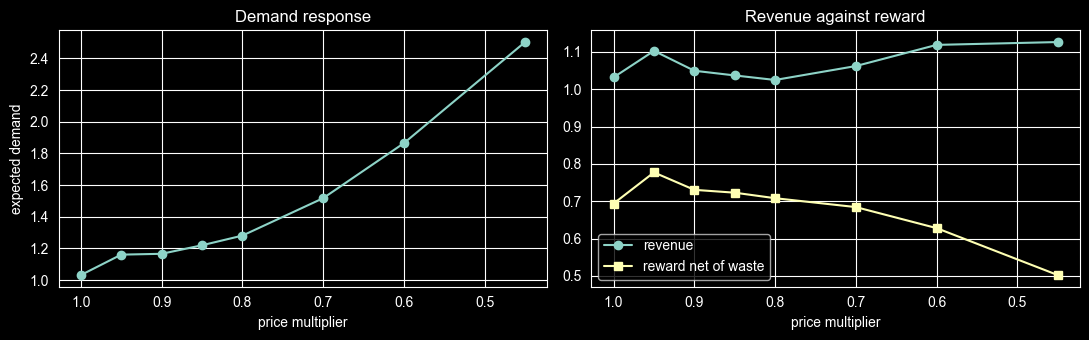

In [3]:
curve = pd.read_csv(RESULTS_DIR / "demand_curve.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(curve["discount"], curve["mean_demand"], marker="o")
axes[0].set(xlabel="price multiplier", ylabel="expected demand",
            title="Demand response")
axes[0].invert_xaxis()

axes[1].plot(curve["discount"], curve["mean_revenue"], marker="o", label="revenue")
axes[1].plot(curve["discount"], curve["mean_reward"], marker="s", label="reward net of waste")
axes[1].set(xlabel="price multiplier", title="Revenue against reward")
axes[1].invert_xaxis()
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demand_curve.png", dpi=150)
plt.show()

**EDIT HERE** — the two panels carry the economic argument: revenue alone
peaks at full price, the waste-aware reward does not.

## 3. Value iteration and the Bellman contraction

The Bellman operator is a gamma-contraction on bounded value functions under
the supremum norm, so Banach's fixed point theorem gives a unique optimal
value function and geometric convergence,

$$\|V_n - V^*\|_\infty \le \gamma^n \|V_0 - V^*\|_\infty .$$

The residual sequence is the empirical counterpart of that bound.

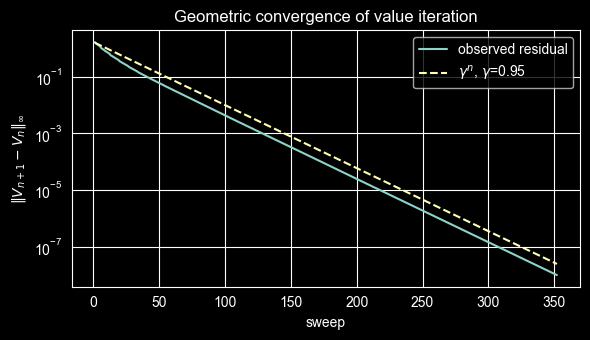

In [4]:
residuals = pd.read_csv(RESULTS_DIR / "vi_residuals.csv")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(residuals["sweep"], residuals["residual"], label="observed residual")
ax.semilogy(residuals["sweep"], residuals["gamma_power"] * residuals["residual"].iloc[0],
            "--", label=fr"$\gamma^n$, $\gamma$={DISCOUNT_FACTOR}")
ax.set(xlabel="sweep", ylabel=r"$\|V_{n+1}-V_n\|_\infty$",
       title="Geometric convergence of value iteration")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vi_convergence.png", dpi=150)
plt.show()

## 4. Decision-focused learning: three losses, three outcomes

All variants share architecture, features, reward and decision layer, so any
difference isolates the training objective.

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\python\\AIDDM_project\\artifacts\\results\\default\\dfl_mse_history.csv'

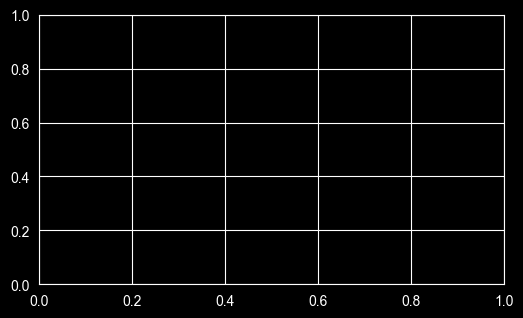

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for loss in ("mse", "spo", "perturbed"):
    history = pd.read_csv(RESULTS_DIR / f"dfl_{loss}_history.csv")
    ax.plot(history["epoch"], history["loss"], label=loss)
ax.axhline(0, color="grey", lw=0.8)
ax.set(xlabel="epoch", ylabel="training loss", title="Training trajectories")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dfl_training.png", dpi=150)
plt.show()

**EDIT HERE** — note that a bound on a non-negative regret cannot go
negative, and that the SPO+ trajectory does.

## 5. The anchor term

A purely decision-aware loss constrains which action wins, never the level of
the prediction. The network drifts in scale until predicted demand exceeds
stock at every action; then `min(demand, stock)` is constant, the waste term
vanishes and the policy collapses to full price. A weak level constraint
removes the drift without reverting to prediction-first training.

In [7]:
sweep = pd.read_csv(RESULTS_DIR / "anchor_sweep.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for loss, part in sweep.groupby("loss"):
    axes[0].plot(part["anchor_weight"], part["mean_predicted_demand"], marker="o", label=loss)
    axes[1].plot(part["anchor_weight"], part["entropy"], marker="o", label=loss)
axes[0].set(xlabel="anchor weight", ylabel="mean predicted demand", title="Scale")
axes[1].set(xlabel="anchor weight", ylabel="action entropy (nats)", title="Policy diversity")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anchor_sweep.png", dpi=150)
plt.show()

sweep.round(4)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\python\\AIDDM_project\\artifacts\\results\\default\\anchor_sweep.csv'

## 6. Policy comparison

Eleven policies scored on the held-out horizon against the same simulator and
the same reward. The clairvoyant policy prices against the model that also
generates the reward, so it is a ceiling rather than a competitor.

In [ ]:
comparison = pd.read_csv(RESULTS_DIR / "policy_comparison.csv", index_col=0)
comparison.round(4)

## 7. Paired differences against the operator's own pricing

Both policies are scored on the same days and the same pairs, so resampling
the difference removes the variance they share. Comparing two independent
intervals instead would overstate the uncertainty of the comparison.

In [ ]:
differences = pd.read_csv(RESULTS_DIR / "paired_differences.csv", index_col=0)
ordered = differences.sort_values("difference")

fig, ax = plt.subplots(figsize=(7, 4))
positions = np.arange(len(ordered))
ax.errorbar(
    ordered["difference"], positions,
    xerr=[ordered["difference"] - ordered["ci_low"],
          ordered["ci_high"] - ordered["difference"]],
    fmt="o", capsize=3,
)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(positions)
ax.set_yticklabels(ordered.index)
ax.set(xlabel="reward difference against the historical policy",
       title="Paired bootstrap, 95% intervals")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "paired_differences.png", dpi=150)
plt.show()

ordered.round(4)

**EDIT HERE** — say which differences are significant and which are not, and
what share of the available headroom each policy recovers.

## 8. What the policies actually do

In [ ]:
distribution = pd.read_csv(RESULTS_DIR / "action_distribution.csv", index_col=0)
share = distribution / distribution.sum()

fig, ax = plt.subplots(figsize=(9, 4))
share.T.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set(xlabel="share of decisions", title="Chosen price multiplier by policy")
ax.legend(title="multiplier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "action_distribution.png", dpi=150)
plt.show()

distribution

## 9. Sensitivity of the policy to the waste penalty

Only the difference between the waste penalty and the unit cost affects the
argmax, because the cost of goods is sunk once the stock is bought. The sweep
documents how much of the resulting policy is driven by that one parameter.

In [ ]:
pd.read_csv(RESULTS_DIR / "reward_sensitivity.csv").round(4)

## 10. The reward surface

The plateau is where predicted demand exceeds stock at every action. There
the reward is flat in the prediction, which is the geometry behind the
decision-focused failures above.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from src.reward import reward_curve

demand_axis = np.linspace(0.1, 5.0, 60)
stock_axis = np.linspace(0.1, 3.0, 60)
mesh_demand, mesh_stock = np.meshgrid(demand_axis, stock_axis)

best = np.array([
    reward_curve(np.array([d]), np.array([s]), GRID).max()
    for d, s in zip(mesh_demand.ravel(), mesh_stock.ravel())
]).reshape(mesh_demand.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(mesh_demand, mesh_stock, best, cmap="viridis", alpha=0.9)
ax.set(xlabel="predicted demand", ylabel="stock", zlabel="best attainable reward",
       title="Reward saturates once demand exceeds stock")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reward_surface.png", dpi=150)
plt.show()

**EDIT HERE** — closing summary: what worked, what failed, and why.